In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [5]:
# loading dataset
# df= pd.read_csv("../datasets/online_retail.csv")    

# The dataset is stored as a ZIP file to reduce its size for GitHub upload.
df = pd.read_csv("../datasets/online_retail.zip", compression="zip")          
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Shape of data
df.shape

(541909, 8)

In [4]:
# last 5 data 
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
# Data Columns
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
# checking for null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# removing null values where customer_id is null
df = df.dropna(subset = ['CustomerID'])

In [9]:
# checking for duplicate values
df.duplicated().sum()

np.int64(5225)

In [10]:
# selecting duplicate values
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [11]:
# removing duplicate values
df = df.drop_duplicates()

In [12]:
# converting the date column to datetime datatype
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
# removing all the cancelled orders ( whose invoice no. starts from c ) and showing the shape of dataset
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(df.shape)

(392732, 8)


In [14]:
# check for invalid value in quantity
df = df[df['Quantity'] > 0]

In [15]:
# check for invalid price 
df = df[df['UnitPrice']>0]

In [16]:
# getting final information of the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.0+ MB


## Data Cleaning Summary

The following preprocessing steps were completed:

- Missing Customer IDs were removed.
- Duplicate records were removed.
- InvoiceDate was converted into datetime format.
- Cancelled transactions were removed.
- Records with non-positive quantities were removed.
- Records with non-positive unit prices were removed.

The cleaned dataset is now ready for descriptive statistics and RFM feature engineering.

In [17]:
# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Display first five rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [18]:
# get the average purchase value of all customers
average_purchase_value = df['TotalAmount'].mean()
print(f"Average Purchase Value: £{average_purchase_value:.2f}")

Average Purchase Value: £22.63


In [19]:
# get the purchase frequency of all customers
purchase_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()
purchase_frequency

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4338, dtype: int64

In [20]:
# get the average purchase frequency of all customers
average_frequency = purchase_frequency.mean()
print(f"Average Frequency: {average_frequency:.2f}")

Average Frequency: 4.27


### Customer Lifetime Value (CLV)
Total amount spent by each Consumer

In [21]:
clv = df.groupby('CustomerID')['TotalAmount'].sum()
clv

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
             ...   
18280.0      180.60
18281.0       80.82
18282.0      178.05
18283.0     2045.53
18287.0     1837.28
Name: TotalAmount, Length: 4338, dtype: float64

In [22]:
# getting customer lifetime value's average value of each customer
clv_average = clv.mean()
print(f"Average CLV: {clv_average:.2f}")

Average CLV: 2048.69


In [23]:
# generate a new dataframe for the average values of purchase, frequency and clv
summary = pd.DataFrame({
    'Metric':[
        'Average Purchase Value',
        'Average Purchase Frequency',
        'Average Customer Lifetime Value'
    ],
    'Value' : [
        round(average_purchase_value,2),
        round(average_frequency,2),
        round(clv_average,2)
    ]    
})
summary

,Metric,Value
0,Average Purchase Value,22.63
1,Average Purchase Frequency,4.27
2,Average Customer Lifetime Value,2048.69


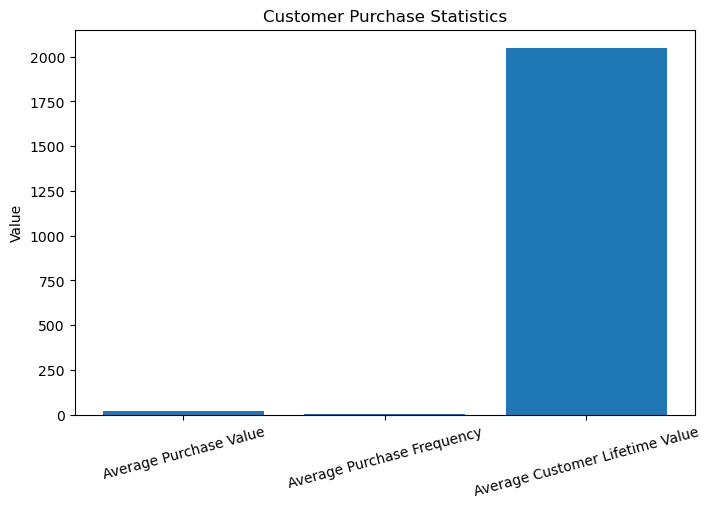

In [24]:
# plot a bar graph for the average values of purchase, frequency and clv
plt.figure(figsize=(8,5))

plt.bar(summary['Metric'], summary['Value'])

plt.title("Customer Purchase Statistics")
plt.ylabel("Value")
plt.xticks(rotation=15)

plt.show()

## Customer Purchase Statistics Summary

The descriptive statistics provide an overview of customer purchasing behavior.

Key metrics calculated include:

- Average Purchase Value
- Average Purchase Frequency
- Average Customer Lifetime Value

These statistics help us understand customer spending patterns and provide the foundation for the RFM analysis performed in the next phase.

## RFM (Recency, Frequency, Monetary) Analysis

RFM Analysis is a customer segmentation technique used to evaluate customer purchasing behavior.

- **Recency (R):** Number of days since the customer's last purchase.
- **Frequency (F):** Total number of purchases made by the customer.
- **Monetary (M):** Total amount spent by the customer.

These three features will be used as input for the K-Means clustering algorithm.

In [25]:
# find the last day of purchase in the dataset
latest_date = df['InvoiceDate'].max()
latest_date

Timestamp('2011-12-09 12:50:00')

In [26]:
# calculate recency based on the last purchase date for each customer

recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (latest_date - recency['InvoiceDate']).dt.days
recency.head()

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


In [27]:
# calculate frequency based on the last purchase date for each customer

frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID' , 'frequency']
frequency.head()

,CustomerID,frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [28]:
# calculate monetary based on the last purchase date for each customer

monetary = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']
monetary.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [29]:
# merge all the three values in a single dataframe to get the value of RFM together

rfm =pd.merge(recency[['CustomerID','Recency']],
              frequency, on ='CustomerID')
rfm = pd.merge(rfm,monetary, on = 'CustomerID')

rfm.head()

,CustomerID,Recency,frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [30]:
# shape
rfm.shape

(4338, 4)

In [31]:
# first five values
rfm.head()

,CustomerID,Recency,frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [32]:
# check for the null values in RFM
rfm.isnull().sum()

CustomerID    0
Recency       0
frequency     0
Monetary      0
dtype: int64

In [33]:
# Stastical values of RFM
rfm.describe()

,CustomerID,Recency,frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,306.482500
50%,15299.500000,50.000000,2.000000,668.570000
75%,16778.750000,141.000000,5.000000,1660.597500
max,18287.000000,373.000000,209.000000,280206.020000


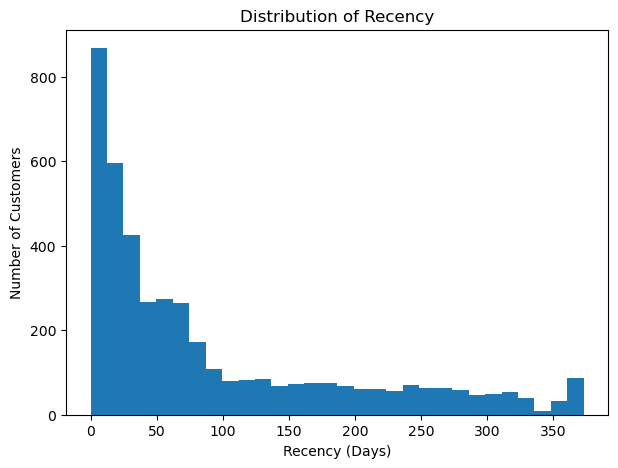

In [34]:
# Graph which shows the distribution of recency among consumers

plt.figure(figsize=(7,5))
plt.hist(rfm['Recency'],bins = 30)
plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.show()

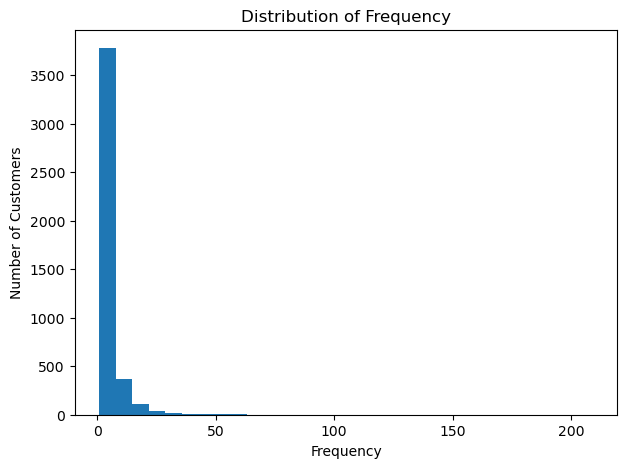

In [35]:
# Graph which shows the distribution of frequency among consumers

plt.figure(figsize=(7,5))
plt.hist(rfm['frequency'],bins = 30)
plt.title('Distribution of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')

plt.show()

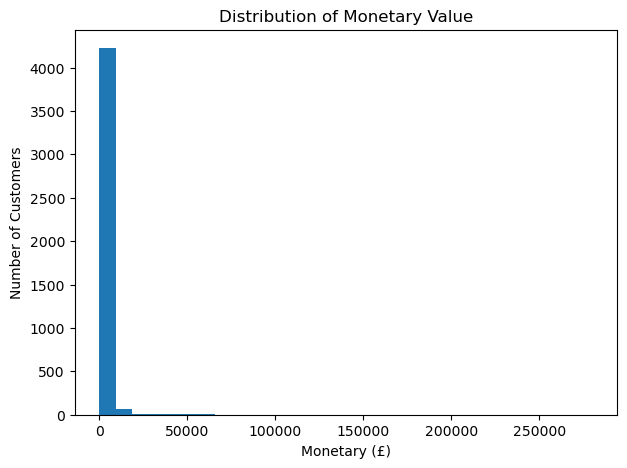

In [36]:
# Graph which shows the distribution of monetary value among consumers

plt.figure(figsize=(7,5))

plt.hist(rfm['Monetary'], bins=30)

plt.title('Distribution of Monetary Value')
plt.xlabel('Monetary (£)')
plt.ylabel('Number of Customers')

plt.show()

## RFM Analysis Summary

RFM features were successfully created for each customer.

These three behavioural features summarize customer purchasing patterns and will be used as the input variables for customer segmentation using the K-Means clustering algorithm.

## Feature Scaling (Standardization)

Machine learning algorithms such as K-Means are sensitive to the scale of input features. Since Recency, Frequency, and Monetary have different ranges, StandardScaler is used to standardize these features before clustering.

This ensures that each feature contributes equally to the clustering process.

In [37]:
# select RFM features
rfm_features = rfm[['Recency','frequency','Monetary']]
rfm_features.head()

,Recency,frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


In [38]:
# Import scikit-learn
from sklearn.preprocessing import StandardScaler

In [39]:
# Initialize satandardscaler
scaler = StandardScaler() 
# standarized
rfm_scaled = scaler.fit_transform(rfm_features)

In [40]:
# Convert back to dataframe
rfm_scaled = pd.DataFrame(rfm_scaled,columns = ['Recency','frequency','Monetary'])
rfm_scaled.head()

,Recency,frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


In [41]:
rfm_scaled.describe().round(2)

,Recency,frequency,Monetary
count,4338.00,4338.00,4338.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.92,-0.43,-0.23
25%,-0.75,-0.43,-0.19
50%,-0.42,-0.30,-0.15
75%,0.49,0.09,-0.04
max,2.81,26.60,30.96


In [42]:
# Display original data and the Scaled data for comparision
print("Original Data")
display(rfm_features.head())

print("Scaled Data")
display(rfm_scaled.head())

Original Data


,Recency,frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


Scaled Data


,Recency,frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


### Observation

The standardized features have a mean close to 0 and a standard deviation close to 1. This confirms that all features are now on a comparable scale and are suitable for K-Means clustering.

## Standarized Summary

The selected RFM features were standardized using StandardScaler.

- Recency
- Frequency
- Monetary

Standardization removes the effect of different measurement scales, allowing the K-Means algorithm to treat all features equally during customer segmentation.

##  Determine the Optimal Number of Clusters (Elbow Method)

Before applying K-Means clustering, it is necessary to determine the optimal number of clusters (K).

The Elbow Method calculates the Within-Cluster Sum of Squares (WCSS) for different values of K. The point where the decrease in WCSS starts slowing down is called the **Elbow Point**, which represents the optimal number of clusters.

In [43]:
# Import Kmeans
from sklearn.cluster import KMeans

In [44]:
# Calculate WCSS
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state = 42,n_init = 10)

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

In [45]:
# display all the values of WCSS for each value of k starting from 1 to 10
for k,value in enumerate (wcss,start = 1):
    print(f"k={k} --> wcss = {value:.2f}")

k=1 --> wcss = 13014.00
k=2 --> wcss = 9014.57
k=3 --> wcss = 5441.32
k=4 --> wcss = 4096.30
k=5 --> wcss = 3119.79
k=6 --> wcss = 2473.79
k=7 --> wcss = 2023.59
k=8 --> wcss = 1717.01
k=9 --> wcss = 1468.79
k=10 --> wcss = 1281.05


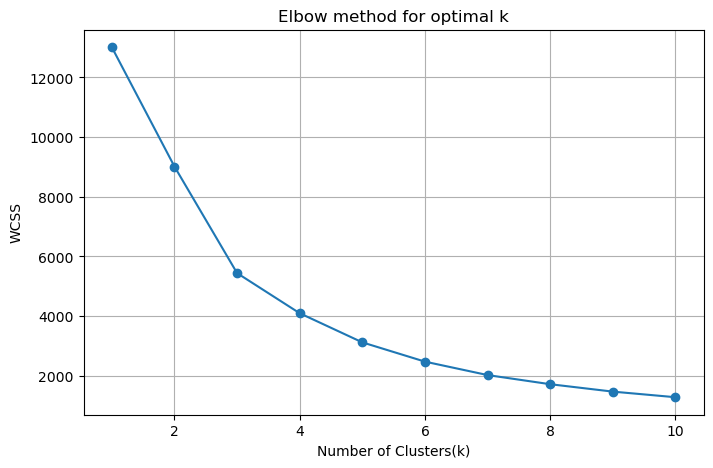

In [46]:
# plot the elbow curve

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker = 'o')
plt.title('Elbow method for optimal k')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [47]:
#  From the elbow curve, we find our optimal value
optimal_k = 3
print("Optimal Number of Clusters:", optimal_k)

Optimal Number of Clusters: 3


## Elbow method Summary

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.

Based on the WCSS values and the Elbow Curve, the optimal number of clusters is 3. This value will be used in the next phase to segment customers into distinct groups.

## K-Means Clustering

After determining the optimal number of clusters using the Elbow Method, the K-Means algorithm is applied to segment customers based on their purchasing behaviour.

The algorithm groups customers with similar Recency, Frequency, and Monetary (RFM) values into distinct clusters.

In [48]:
# Train using Kmeans

kmeans = KMeans(n_clusters = optimal_k, random_state = 42, n_init = 10)
kmeans.fit(rfm_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


### Observation

The K-Means model was trained using the standardized RFM features. Each customer will now be assigned to one of the identified clusters.

In [49]:
# Assign cluster labels
rfm['Cluster'] = kmeans.labels_

# Display first five rows
rfm.head()

,CustomerID,Recency,frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,0
1,12347.0,1,7,4310.00,1
2,12348.0,74,4,1797.24,1
3,12349.0,18,1,1757.55,1
4,12350.0,309,1,334.40,0


### Observation

Each customer has been assigned to a cluster based on similarities in Recency, Frequency, and Monetary values.

In [50]:
# Number of customers in each cluster
rfm['Cluster'].value_counts().sort_index()

Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

In [51]:
# Cluster centers (scaled values)
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=['Recency', 'Frequency', 'Monetary']
)

cluster_centers

,Recency,Frequency,Monetary
0,1.545658,-0.349451,-0.157947
1,-0.510809,0.052064,-0.022152
2,-0.864957,8.074597,9.324975


### Observation

The cluster centers represent the average standardized RFM values for each cluster. These values help understand how the clusters differ from one another.

In [52]:
# Sample customers from each cluster
rfm.groupby('Cluster').head(5)

,CustomerID,Recency,frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,0
1,12347.0,1,7,4310.00,1
2,12348.0,74,4,1797.24,1
3,12349.0,18,1,1757.55,1
4,12350.0,309,1,334.40,0
5,12352.0,35,8,2506.04,1
6,12353.0,203,1,89.00,0
7,12354.0,231,1,1079.40,0
8,12355.0,213,1,459.40,0
9,12356.0,22,3,2811.43,1


In [53]:
# Number of customers in each cluster
cluster_summary = rfm.groupby('Cluster').size().reset_index(name='Customer Count')

cluster_summary

,Cluster,Customer Count
0,0,1082
1,1,3230
2,2,26


## Summary

The K-Means algorithm successfully segmented customers into distinct clusters using their standardized RFM features.

Each customer has been assigned a cluster label, which will be used in the next phase to visualize customer segments and analyze their characteristics.

## Cluster Visualization

After applying K-Means clustering, the resulting customer segments are visualized to better understand the relationship between Recency, Frequency, and Monetary values.

Scatter plots help identify how customers are distributed across different clusters, while a bar chart shows the number of customers in each cluster.

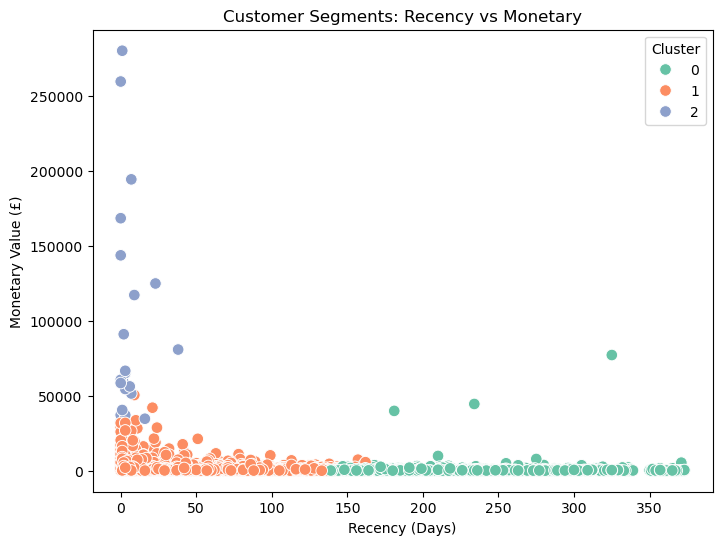

In [54]:
# Scatter Plot: Recency vs Monetary

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value (£)")
plt.legend(title="Cluster")

plt.show()

### Observation

The scatter plot shows how customers are grouped based on how recently they made a purchase and how much they have spent. Customers belonging to the same cluster exhibit similar purchasing behaviour.

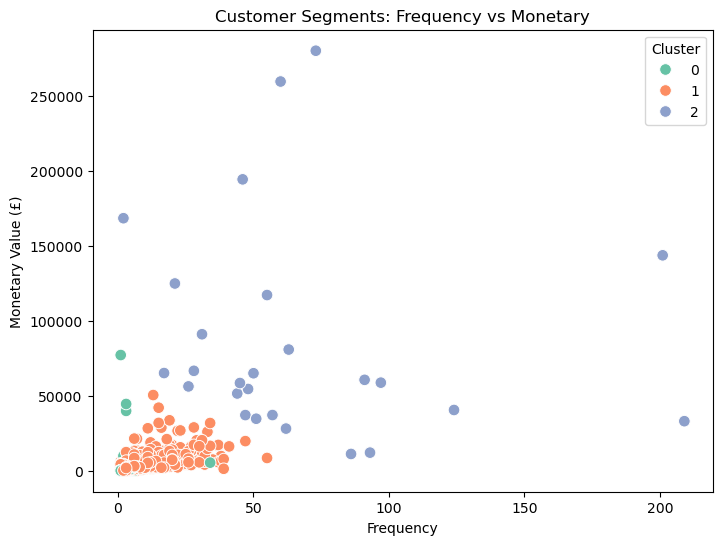

In [55]:
# Scatter Plot: Frequency vs Monetary

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value (£)")
plt.legend(title="Cluster")

plt.show()

### Observation

Customers with higher purchase frequency generally have higher monetary values. The clusters clearly separate customers with different purchasing patterns.

In [56]:
# Bar Chart: Customers per Cluster

cluster_counts = rfm['Cluster'].value_counts().sort_index()

cluster_counts

Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

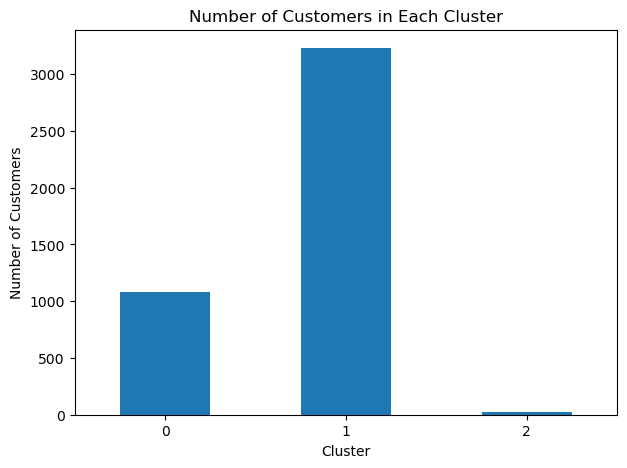

In [57]:
plt.figure(figsize=(7,5))

cluster_counts.plot(kind='bar')

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

### Observation

The bar chart represents the distribution of customers across different clusters. It helps identify whether the customer segments are balanced or if one segment contains significantly more customers than the others.

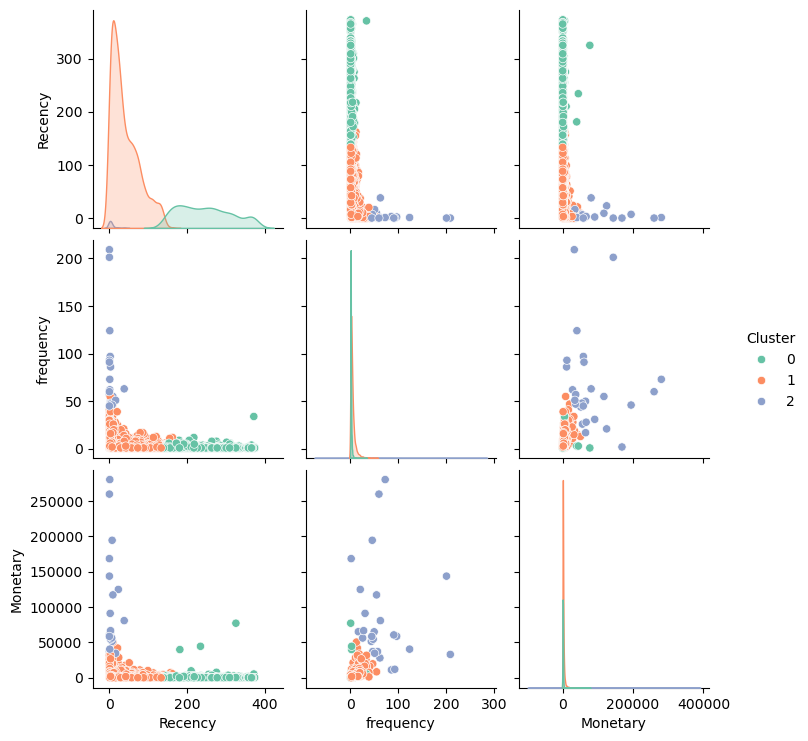

In [58]:
# Pair Plot

sns.pairplot(
    rfm,
    vars=['Recency', 'frequency', 'Monetary'],
    hue='Cluster',
    palette='Set2'
)

plt.show()

## Visualization Summary

The customer segments were visualized using scatter plots and a bar chart.

- **Recency vs Monetary** illustrates the relationship between recent purchases and customer spending.
- **Frequency vs Monetary** highlights differences in purchasing frequency and total expenditure.
- **Customers per Cluster** shows the size of each customer segment.

These visualizations make it easier to interpret the clusters before profiling them in the next phase.

## Customer Cluster Profiling

After segmenting customers using K-Means clustering, each cluster is analyzed by calculating the average Recency, Frequency, and Monetary values.

This helps identify the characteristics of each customer segment and provides meaningful business interpretations.

In [59]:
# Calculate average RFM values for each cluster
cluster_profile = rfm.groupby('Cluster')[['Recency', 'frequency', 'Monetary']].mean().round(2)

cluster_profile

,Recency,frequency,Monetary
Cluster,,,
0,246.11,1.58,629.66
1,40.45,4.67,1849.67
2,5.04,66.42,85826.08


#### Observation

The average RFM values help distinguish customer behaviour across different clusters. Customers within the same cluster have similar purchasing patterns.

In [60]:
# Number of customers in each cluster
customer_count = rfm.groupby('Cluster').size()

# Add customer count to profile
cluster_profile['Customer Count'] = customer_count

cluster_profile

,Recency,frequency,Monetary,Customer Count
Cluster,,,,
0,246.11,1.58,629.66,1082
1,40.45,4.67,1849.67,3230
2,5.04,66.42,85826.08,26


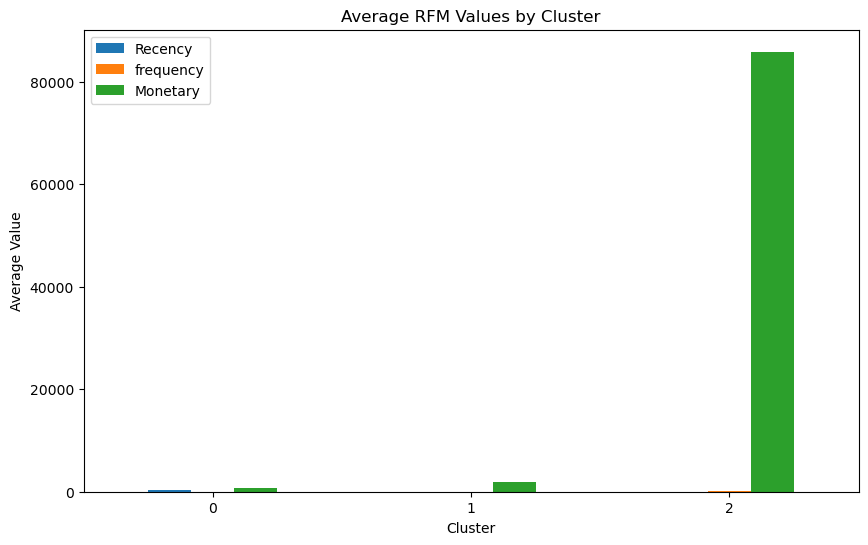

In [61]:
cluster_profile[['Recency','frequency','Monetary']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Average RFM Values by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

#### Observation

The bar chart compares the average Recency, Frequency, and Monetary values of each customer cluster, making it easier to identify behavioural differences between customer groups.

In [62]:
cluster_profile

,Recency,frequency,Monetary,Customer Count
Cluster,,,,
0,246.11,1.58,629.66,1082
1,40.45,4.67,1849.67,3230
2,5.04,66.42,85826.08,26


### Customer Segment Interpretation

### Cluster 0 – Inactive Customers

- Highest average Recency (246.11 days), indicating these customers have not purchased recently.
- Lowest purchase frequency (1.58 orders).
- Lowest average spending (£629.66).
- Contains 1,082 customers.

These customers have low engagement and contribute relatively little revenue. They may have stopped purchasing or are at risk of being lost.

---

### Cluster 1 – Regular Customers

- Moderate Recency (40.45 days), indicating fairly recent purchases.
- Moderate purchase frequency (4.67 orders).
- Moderate average spending (£1,849.67).
- Largest customer segment with 3,230 customers.

These customers form the core customer base. They purchase regularly and generate steady revenue for the business.

---

### Cluster 2 – High Value (VIP) Customers

- Lowest Recency (5.04 days), indicating very recent purchases.
- Highest purchase frequency (66.42 orders).
- Highest average spending (£85,826.08).
- Smallest segment with only 26 customers.

These customers are the most valuable to the business. Although they represent less than 1% of the customer base, they contribute significantly to overall revenue.

## Marketing Recommendations

### Cluster 0 – Inactive Customers

These customers have not purchased for a long time and spend less money.

**Recommended Actions:**
- Send reminder emails about new products.
- Give small discount coupons to attract them.
- Share special festival or seasonal offers.
- Ask for their feedback to understand why they stopped buying.

---

### Cluster 1 – Regular Customers

These customers buy products regularly and are important for the business.

**Recommended Actions:**
- Give reward points on every purchase.
- Offer "Buy More, Save More" deals.
- Suggest products based on their previous orders.
- Send thank-you messages to keep them engaged.

---

### Cluster 2 – High Value Customers

These customers purchase very frequently and spend the highest amount.

**Recommended Actions:**
- Give exclusive VIP benefits.
- Offer early access to new products.
- Provide special gifts on large purchases.
- Give priority customer support.
- Thank them with personalized appreciation messages.

## Overall Project Insights

- The customer data was successfully divided into three different groups using the K-Means clustering algorithm.
- Most customers belong to Cluster 1, showing that they shop regularly and contribute steady sales.
- Cluster 0 contains customers who have not purchased for a long time and may need special offers to return.
- Cluster 2 has only a few customers, but they spend much more than others and are the most valuable customers.
- Customer segmentation helps businesses understand different customer behaviors and create better marketing strategies for each group.
- By giving the right offers to the right customers, businesses can improve customer satisfaction, increase sales, and build long-term customer relationships.